# 03 - Consultas Analíticas (SQL)
``Trabalho Prático 2 — DCC011: Introdução a Banco de Dados``

Este notebook executa as 10 consultas obrigatórias exigidas para a avaliação do projeto. As consultas estão estruturadas por níveis crescentes de complexidade, extraindo métricas diretamente do banco de dados relacional normalizado em Terceira Forma Normal (`contratos.db`).

---
## Configuração Inicial do Ambiente

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Definindo configurações visuais para os gráficos do relatório
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (11, 5)

# Função auxiliar para executar e exibir as consultas de forma padronizada
def executar_consulta(sql_query, titulo):
    conn = sqlite3.connect('contratos.db')
    df = pd.read_sql_query(sql_query, conn)
    conn.close()
    print(f"\n{"="*20} {titulo} {"="*20}\n")
    return df

### Consulta 1: Mapeamento de Processos de RAN Sharing
**Descrição:** Realiza a projeção de colunas fundamentais e faz uma seleção para isolar estritamente os acordos de compartilhamento de rede de acesso via rádio (RAN Sharing).

In [2]:
query_1 = """
SELECT id_contrato, tipo_contrato, id_processo 
FROM contrato 
WHERE tipo_contrato = 'ran_sharing';
"""
df_1 = executar_consulta(query_1, "CONTRATOS DE RAN SHARING")
df_1.head()


==================== CONTRATOS DE RAN SHARING ====================



,id_contrato,tipo_contrato,id_processo
0,5064,ran_sharing,53500.000608/2020-11
1,5065,ran_sharing,53500.001089/2014-61
2,5066,ran_sharing,53500.001164/2021-12
3,5067,ran_sharing,53500.001341/2014-31
4,5068,ran_sharing,53500.002241/2016-94


### Consulta 2: Rastreamento de Alterações Contratuais Recentes
**Descrição:** Seleciona e projeta versões ou aditivos contratuais estabelecidos a partir de 2024 que possuem uma data explícita de encerramento da vigência acordada.

In [4]:
query_2 = """
SELECT id_versao, id_contrato, protocolo_data, conclusao_data 
FROM versao_contrato 
WHERE protocolo_data >= '2024-01-01' AND conclusao_data IS NOT NULL
ORDER BY protocolo_data DESC;
"""
df_2 = executar_consulta(query_2, "VERSÕES RECENTES (>= 2024)")
display(df_2.head())


==================== VERSÕES RECENTES (>= 2024) ====================



,id_versao,id_contrato,protocolo_data,conclusao_data
0,22160,4947,2025-06-03,2025-06-16
1,22098,4902,2025-05-29,2025-06-16
2,22148,4939,2025-05-23,2025-06-16
3,22015,4849,2025-05-21,2025-06-02
4,22131,4928,2025-05-21,2025-06-02


### Consulta 3: Junção de Contratos e Histórico de Versões
**Descrição:** Realiza uma junção simples (`INNER JOIN`) entre a tabela mãe de contratos e seu histórico de versões para reconstruir a linha do tempo dos aditivos administrativos.

In [5]:
query_3 = """
SELECT c.id_processo, c.tipo_contrato, v.num_sequencia, v.protocolo_data 
FROM contrato c 
INNER JOIN versao_contrato v ON c.id_contrato = v.id_contrato
LIMIT 10;
"""
df_3 = executar_consulta(query_3, "LINHA DO TEMPO DOS CONTRATOS")
df_3


==================== LINHA DO TEMPO DOS CONTRATOS ====================



,id_processo,tipo_contrato,num_sequencia,protocolo_data
0,53500.000052/2006-13,interconexao,1,2014-10-20
1,53500.000052/2006-13,interconexao,2,2014-10-20
2,53500.000081/2020-25,interconexao,1,2021-05-04
3,53500.000081/2020-25,interconexao,2,2021-05-04
4,53500.000081/2020-25,interconexao,3,2021-05-04
5,53500.000081/2020-25,interconexao,4,2021-05-04
6,53500.000081/2020-25,interconexao,5,2021-05-04
7,53500.000081/2020-25,interconexao,6,2021-05-04
8,53500.000081/2020-25,interconexao,7,2021-05-04
9,53500.000081/2020-25,interconexao,8,2021-05-04


### Consulta 4: Papel Regulatório das Operadoras por Versão
**Descrição:** Conecta a tabela associativa de participações ao cadastro mestre de empresas para expor quais razões sociais atuam em cada ID de versão contratual.

In [7]:
query_4 = """
SELECT p.id_versao, e.razao_social, p.papel 
FROM participacao p 
INNER JOIN empresa e ON p.id_empresa = e.id_empresa
LIMIT 10;
"""
df_4 = executar_consulta(query_4, "PAPÉIS REGULATÓRIOS DAS EMPRESAS")
df_4


==================== PAPÉIS REGULATÓRIOS DAS EMPRESAS ====================



,id_versao,razao_social,papel
0,1,TIM CELULAR S.A.,PRESTADORA_1
1,1,OI S.A. - EM RECUPERACAO JUDICIAL,PRESTADORA_2
2,2,TIM CELULAR S.A.,PRESTADORA_1
3,2,OI S.A. - EM RECUPERACAO JUDICIAL,PRESTADORA_2
4,3,TIM S A,PRESTADORA_1
5,3,DEFFERRARI SOLUCOES EM INTERNET LTDA,PRESTADORA_2
6,4,TIM S A,PRESTADORA_1
7,4,DEFFERRARI SOLUCOES EM INTERNET LTDA,PRESTADORA_2
8,5,TIM S A,PRESTADORA_1
9,5,DEFFERRARI SOLUCOES EM INTERNET LTDA,PRESTADORA_2


### Consulta 5: Catálogo de Empresas com Vínculos Contratuais Ativos
**Descrição:** Junção entre empresas e participações filtrando operadoras que possuem CNPJs válidos e participações homologadas no sistema.

In [8]:
query_5 = """
SELECT DISTINCT e.razao_social, e.cnpj 
FROM empresa e 
INNER JOIN participacao p ON e.id_empresa = p.id_empresa 
WHERE e.cnpj IS NOT NULL
LIMIT 10;
"""
df_5 = executar_consulta(query_5, "EMPRESAS ATIVAS NO ECOSSISTEMA")
df_5


==================== EMPRESAS ATIVAS NO ECOSSISTEMA ====================



,razao_social,cnpj
0,OI S.A. - EM RECUPERACAO JUDICIAL,76.535.764/0001-43
1,ALGAR TELECOM S/A,71.208.516/0001-74
2,R2 DADOS LTDA,25.070.521/0001-46
3,CONECTV LTDA,17.347.928/0001-40
4,CWMC TELECOM LTDA,22.897.497/0001-25
5,GOLD TELECOM LTDA,10.822.045/0001-03
6,VIVAS TELECOMUNICACOES LTDA,31.976.241/0001-02
7,CIABRASNET CENTRAL BRASILEIRA DE INTERNET LTDA.,10.731.345/0001-79
8,MEGA WIFI SERVICOS E INTERNET LTDA,27.367.809/0001-02
9,MLS WIRELESS TELECOMUNICACOES S.A.,31.679.022/0001-53


### Consulta 6: Rastreamento Completo de Transações Administrativas
**Descrição:** Junção quádrupla unindo `contrato`, `versao_contrato`, `participacao` e `empresa` para recompor a cadeia informacional completa de cada processo regulatório.

In [10]:
query_6 = """
SELECT c.tipo_contrato, c.id_processo, e.razao_social, p.papel 
FROM contrato c 
INNER JOIN versao_contrato v ON c.id_contrato = v.id_contrato 
INNER JOIN participacao p    ON v.id_versao = p.id_versao 
INNER JOIN empresa e         ON p.id_empresa = e.id_empresa
LIMIT 10;
"""
df_6 = executar_consulta(query_6, "RAIO-X COMPLETO DOS PROCESSOS")
df_6


==================== RAIO-X COMPLETO DOS PROCESSOS ====================



,tipo_contrato,id_processo,razao_social,papel
0,interconexao,53500.000052/2006-13,TIM CELULAR S.A.,PRESTADORA_1
1,interconexao,53500.000052/2006-13,OI S.A. - EM RECUPERACAO JUDICIAL,PRESTADORA_2
2,interconexao,53500.000052/2006-13,TIM CELULAR S.A.,PRESTADORA_1
3,interconexao,53500.000052/2006-13,OI S.A. - EM RECUPERACAO JUDICIAL,PRESTADORA_2
4,interconexao,53500.000081/2020-25,TIM S A,PRESTADORA_1
5,interconexao,53500.000081/2020-25,DEFFERRARI SOLUCOES EM INTERNET LTDA,PRESTADORA_2
6,interconexao,53500.000081/2020-25,TIM S A,PRESTADORA_1
7,interconexao,53500.000081/2020-25,DEFFERRARI SOLUCOES EM INTERNET LTDA,PRESTADORA_2
8,interconexao,53500.000081/2020-25,TIM S A,PRESTADORA_1
9,interconexao,53500.000081/2020-25,DEFFERRARI SOLUCOES EM INTERNET LTDA,PRESTADORA_2


### Consulta 7: Análise Espacial do Mercado de MVNOs
**Descrição:** Cruza quatro tabelas aplicando uma restrição na relação primária para mapear exclusivamente os atores envolvidos nos acordos de operadoras móveis virtuais.

In [11]:
query_7 = """
SELECT c.id_processo, v.protocolo_data, e.razao_social, p.papel 
FROM contrato c 
INNER JOIN versao_contrato v ON c.id_contrato = v.id_contrato 
INNER JOIN participacao p    ON v.id_versao = p.id_versao 
INNER JOIN empresa e         ON p.id_empresa = e.id_empresa 
WHERE c.tipo_contrato = 'mvno'
LIMIT 10;
"""
df_7 = executar_consulta(query_7, "DETALHAMENTO DE CONTRATOS MVNO")
df_7


==================== DETALHAMENTO DE CONTRATOS MVNO ====================



,id_processo,protocolo_data,razao_social,papel
0,53500.000262/2015-94,2015-01-07,TELEFONICA BRASIL S.A.,PRESTADORA_ORIGEM
1,53500.000262/2015-94,2015-01-07,MAIS AD CREDENCIADA DE TELEFONIA S.A.,CREDENCIADA
2,53500.000262/2015-94,2017-05-23,TELEFONICA BRASIL S.A.,PRESTADORA_ORIGEM
3,53500.000262/2015-94,2017-05-23,MAIS AD CREDENCIADA DE TELEFONIA S.A.,CREDENCIADA
4,53500.000563/2022-47,2022-01-04,TELEXPERTS TELECOMUNICACOES S.A.,PRESTADORA_ORIGEM
5,53500.000563/2022-47,2022-01-04,P4 TELECOM LTDA,CREDENCIADA
6,53500.001132/2020-36,2019-12-02,SURF TELECOM SA,PRESTADORA_ORIGEM
7,53500.001132/2020-36,2019-12-02,WANTEL TECNOLOGIA LTDA - PPP,CREDENCIADA
8,53500.001813/2023-47,2023-01-10,NEXT LEVEL TELECOM LTDA.,PRESTADORA_ORIGEM
9,53500.001813/2023-47,2023-01-10,KORE BRASIL LTDA,CREDENCIADA


### Consulta 8: Auditoria de Propriedade de Infraestrutura Passiva
**Descrição:** Identifica quais corporações atuam especificamente no papel de "DETENTORA" de ativos físicos (torres, postes e dutos) em contratos de compartilhamento.

In [12]:
query_8 = """
SELECT c.id_processo, v.protocolo_data, e.razao_social AS empresa_detentora 
FROM contrato c 
INNER JOIN versao_contrato v ON c.id_contrato = v.id_contrato 
INNER JOIN participacao p    ON v.id_versao = p.id_versao 
INNER JOIN empresa e         ON p.id_empresa = e.id_empresa 
WHERE c.tipo_contrato = 'compartilhamento' AND p.papel = 'DETENTORA'
LIMIT 10;
"""
df_8 = executar_consulta(query_8, "PROPRIETÁRIAS DE INFRAESTRUTURA")
df_8


==================== PROPRIETÁRIAS DE INFRAESTRUTURA ====================



,id_processo,protocolo_data,empresa_detentora
0,48513.023648/2015-95,2013-06-12,CELESC DISTRIBUIÇÃO S.A.
1,48526.000122/2015-98,2015-01-23,AES SUL DISTRIBUIDORA GAÚCHA DE ENERGIA S.A.
2,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
3,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
4,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
5,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
6,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
7,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
8,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
9,48526.000122/2015-98,2015-08-05,COPEL DISTRIBUIÇÃO S.A.


### Consulta 9: Análise de Volatilidade Contratual por Processo
**Descrição:** Agrupa dados de junção e computa a função agregada `COUNT` para mapear os 10 contratos que sofreram maior volume de aditivos e reajustes históricos.


==================== TOP 10 PROCESSOS COM MAIS ADITIVOS ====================



,id_processo,tipo_contrato,total_versoes
0,53500.000155/2024-57,interconexao,960
1,53500.015705/2022-71,interconexao,468
2,53500.060352/2021-82,compartilhamento,452
3,53500.323929/2022-53,interconexao,441
4,53500.001117/2023-31,interconexao,384
5,53500.064116/2021-35,interconexao,312
6,53500.033103/2021-14,interconexao,192
7,53500.055620/2021-44,interconexao,180
8,53500.019526/2025-55,interconexao,160
9,53500.000900/2016-58,compartilhamento,158


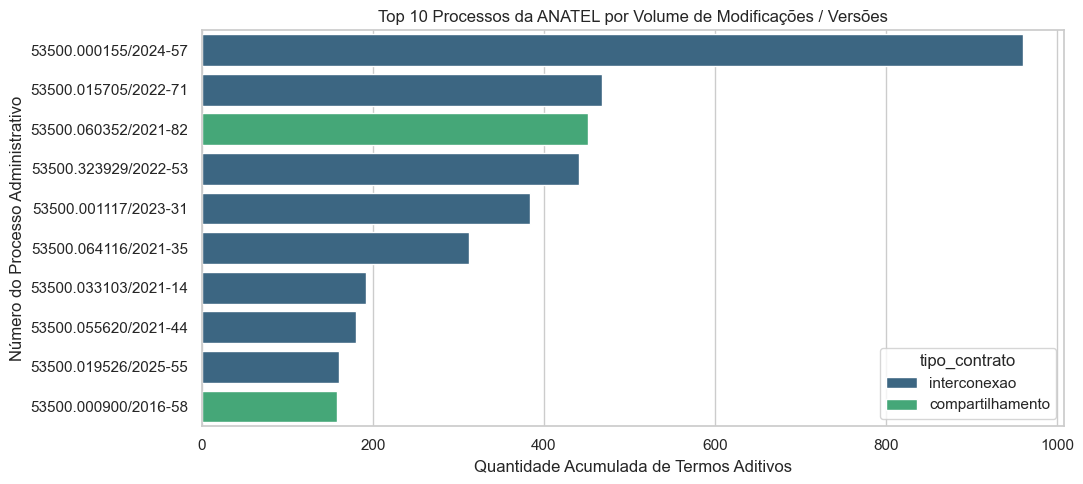

In [13]:
query_9 = """
SELECT c.id_processo, c.tipo_contrato, COUNT(v.id_versao) AS total_versoes 
FROM contrato c 
INNER JOIN versao_contrato v ON c.id_contrato = v.id_contrato 
GROUP BY c.id_contrato 
ORDER BY total_versoes DESC 
LIMIT 10;
"""
df_9 = executar_consulta(query_9, "TOP 10 PROCESSOS COM MAIS ADITIVOS")
display(df_9)

# Plotagem Gráfica para a Seção 6 do Relatório
plt.figure(figsize=(11, 5))
sns.barplot(data=df_9, x='total_versoes', y='id_processo', hue='tipo_contrato', palette='viridis', dodge=False)
plt.title('Top 10 Processos da ANATEL por Volume de Modificações / Versões')
plt.xlabel('Quantidade Acumulada de Termos Aditivos')
plt.ylabel('Número do Processo Administrativo')
plt.tight_layout()
plt.show()

### Consulta 10: Índice de Concentração de Mercado em Compartilhamento Passivo
**Descrição:** Executa um agrupamento por empresa e calcula o volume total de participações contratuais vigentes na modalidade de compartilhamento de infraestrutura, expondo os principais players do setor.


==================== CONCENTRAÇÃO DE MERCADO - COMPARTILHAMENTO ====================



,empresa,total_participacoes
0,CEMIG DISTRIBUIÇÃO S.A.,1514
1,COPEL DISTRIBUIÇÃO S.A.,1377
2,COMPANHIA ENERGÉTICA DO CEARÁ - COELCE,630
3,ELETROPAULO METROPOLITANA ELETRICIDADE DE SÃO ...,493
4,CELESC DISTRIBUIÇÃO S.A.,384
5,COMPANHIA PAULISTA DE FORÇA E LUZ - CPFL,263
6,CELG DISTRIBUIÇÃO S.A - CELG D,250
7,AMPLA ENERGIA E SERVIÇOS S.A.,249
8,COMPANHIA ENERGÉTICA DE PERNAMBUCO - CELPE,235
9,COMPANHIA PAULISTA DE FORÇA E LUZ - CPFL (MATRIZ),217


C:\Users\co275\AppData\Local\Temp\ipykernel_13772\1606509584.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_10, x='total_participacoes', y='empresa', palette='magma')


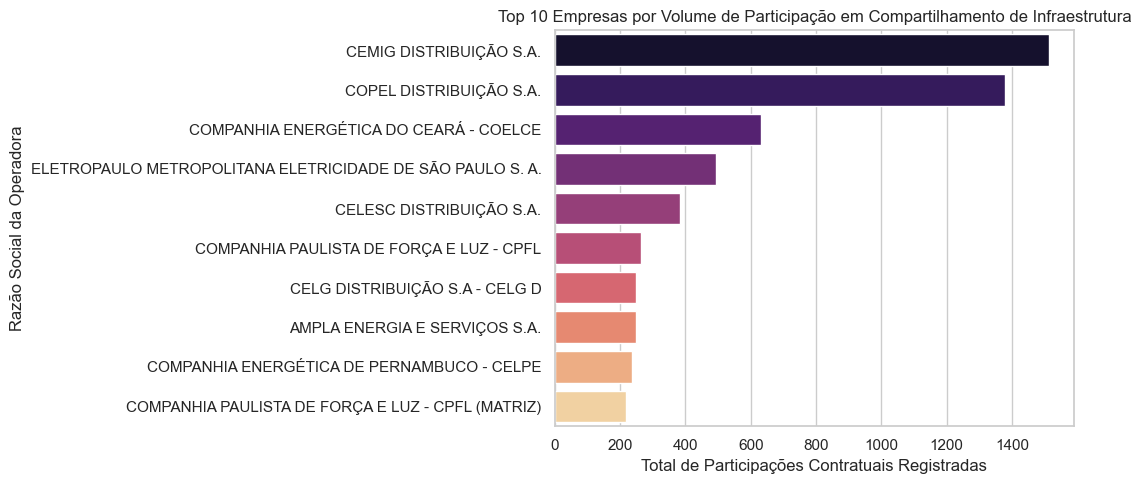

In [14]:
query_10 = """
SELECT e.razao_social AS empresa, COUNT(p.id_participacao) AS total_participacoes 
FROM empresa e 
INNER JOIN participacao p ON e.id_empresa = p.id_empresa 
INNER JOIN versao_contrato v ON p.id_versao = v.id_versao 
INNER JOIN contrato c ON v.id_contrato = c.id_contrato 
WHERE c.tipo_contrato = 'compartilhamento'
GROUP BY e.id_empresa 
ORDER BY total_participacoes DESC 
LIMIT 10;
"""
df_10 = executar_consulta(query_10, "CONCENTRAÇÃO DE MERCADO - COMPARTILHAMENTO")
display(df_10)

# Plotagem Gráfica para a Seção 6 do Relatório
plt.figure(figsize=(11, 5))
sns.barplot(data=df_10, x='total_participacoes', y='empresa', palette='magma')
plt.title('Top 10 Empresas por Volume de Participação em Compartilhamento de Infraestrutura')
plt.xlabel('Total de Participações Contratuais Registradas')
plt.ylabel('Razão Social da Operadora')
plt.tight_layout()
plt.show()